<a href="https://colab.research.google.com/github/stnguswnd/LLM_Agent_Colab/blob/main/260601_langgraph_multi_agent_supervision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agent Supervisor 기초예제
## 작성자 : AISchool ( http://aischool.ai/%ec%98%a8%eb%9d%bc%ec%9d%b8-%ea%b0%95%ec%9d%98-%ec%b9%b4%ed%85%8c%ea%b3%a0%eb%a6%ac/ )
## Reference : https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/

이전 예시에서는 초기 리서처 에이전트의 출력에 따라 메시지가 자동으로 라우팅되었습니다.

우리는 또한 **LLM을 사용하여 다양한 에이전트를 조정(orchestrate)**할 수 있습니다.

아래에서는 **작업을 위임(delegate)하는 데 도움을 주는 에이전트 감독관(agent supervisor)과 함께 에이전트 그룹**을 만들 것입니다.









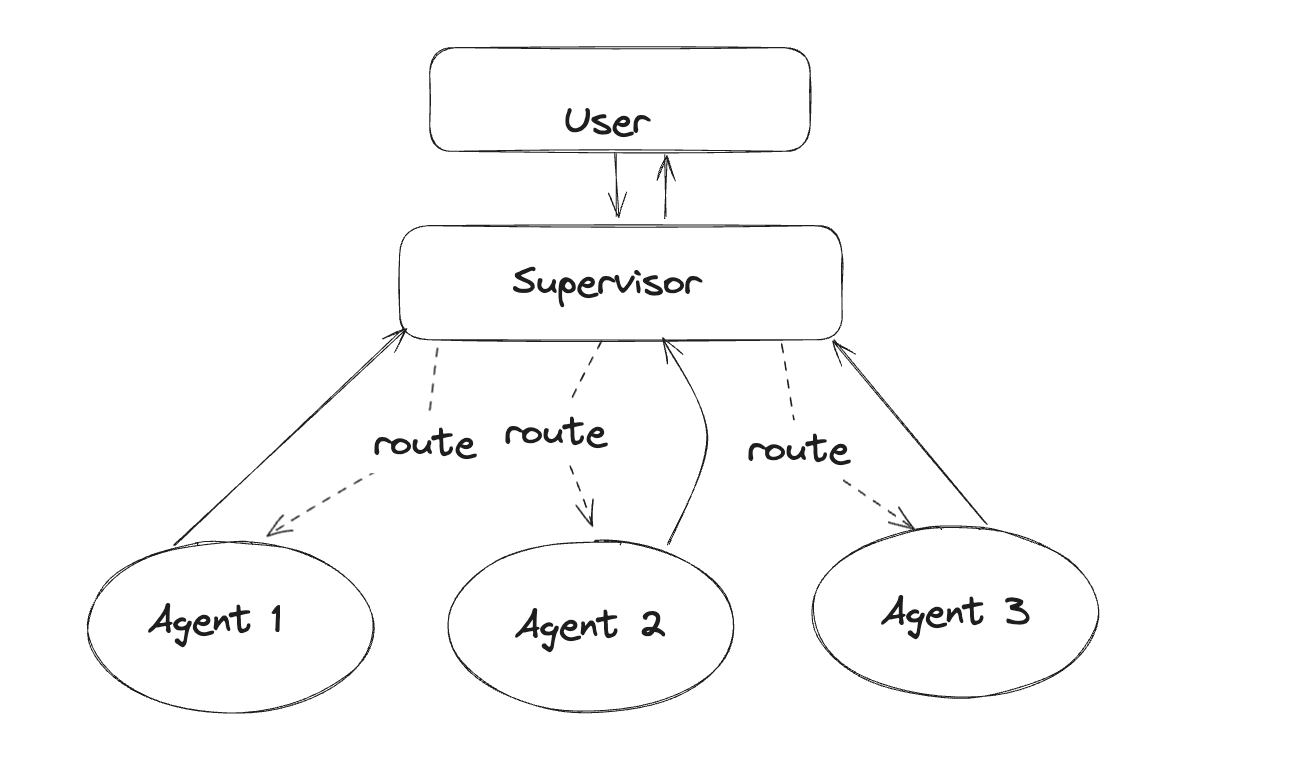

각 에이전트 노드의 코드를 단순화하기 위해, 우리는 LangChain의 AgentExecutor 클래스를 사용할 것입니다. 이 "고급 에이전트"("advanced agent") 노트북과 다른 노트북들은 LangGraph에서 특정 디자인 패턴을 구현하는 방법을 보여주기 위해 설계되었습니다. 만약 해당 패턴이 당신의 요구에 맞는다면, 최상의 성능을 위해 문서의 다른 기본 패턴들과 결합하는 것을 권장합니다.

# 라이브러리 설치

In [1]:
!pip install langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core duckduckgo-search langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


# API Key 설정

In [2]:
import os
from uuid import uuid4

unique_id = uuid4().hex[0:8]
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"Basic Agent Supervisor - {unique_id}"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

from google.colab import userdata
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGCHAIN_API_KEY")
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")


In [3]:
unique_id

'9eb8aefb'

In [ ]:
os.environ["OPENAI_API_KEY"] = "여러분의_OPENAI_API_KEY"

In [ ]:
os.environ["TAVILY_API_KEY"] = "여러분의_TAVILY_API_KEY"

# Create tools

이 예시에서는 **검색 엔진을 사용해 웹 리서치(web research)를 수행하는 에이전트**와 **그래프를 생성하는 에이전트**를 만들 것입니다. 그들이 사용할 도구를 아래에 정의하세요.

In [4]:
from typing import Annotated

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_experimental.tools import PythonREPLTool

tavily_tool = TavilySearchResults(max_results=5)

# This executes code locally, which can be unsafe
python_repl_tool = PythonREPLTool()

/tmp/ipykernel_943/3458434945.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
/tmp/ipykernel_943/3458434945.py:4: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.tools import PythonREPLTool
/tmp/ipykernel_943/3458434945.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavil

# Helper Utilities

그래프에서 노드를 생성하는 데 사용할 헬퍼 함수를 정의하세요. 이 함수는 **에이전트 응답을 사람의 메시지로 변환하는 작업을 처리**합니다. **이는 그래프의 글로벌 상태에 추가하는 방법이기 때문에 중요**합니다.


In [5]:
from langchain_core.messages import HumanMessage

def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {"messages": [HumanMessage(content=result["messages"][-1].content, name=name)]}

# Create Agent Supervisor


이 함수는 **함수 호출(function calling)을 사용**하여 **다음 작업자 노드를 선택하거나 처리를 완료(finish)**합니다.

In [6]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from enum import Enum
from pydantic import BaseModel
from typing import Literal

members = ["Researcher", "Coder"]
system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    " following workers:  {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

# Our team supervisor is an LLM node. It just picks the next agent to process
# and decides when the work is completed
options = ["FINISH"] + members
class routeResponse(BaseModel):
    next: Literal["FINISH", "Researcher", "Coder"]

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
        (
            "system",
            "Given the conversation above, who should act next?"
            " Or should we FINISH? Select one of: {options}",
        ),
    ]
).partial(options=str(options), members=", ".join(members))


llm = ChatOpenAI(model="gpt-4o")

def supervisor_agent(state):
    supervisor_chain = (
        prompt
        | llm.with_structured_output(routeResponse)
    )
    return supervisor_chain.invoke(state)

In [ ]:
# 다음 작업자들 간의 대화를 관리하는 관리자로서 당신은 다음 작업을 수행해야 합니다: {members}.
# 아래의 사용자 요청을 참고하여, 다음 작업을 수행할 작업자를 지정하세요.
# 각 작업자는 작업을 수행하고 그 결과와 상태를 보고할 것입니다.
# 모든 작업이 완료되면 "FINISH"로 응답하세요.

In [ ]:
# 위 대화를 참고하여, 누가 다음으로 행동해야 하나요?
# 아니면 작업을 FINISH해야 하나요?
# 다음 중 하나를 선택하세요: {options}

# Construct Graph

이제 그래프를 구축할 준비가 되었습니다. 아래에, 방금 정의한 함수를 사용하여 상태 및 작업자 노드를 정의하세요.








In [11]:
import functools
import operator
from typing import Sequence, TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import create_react_agent

# The agent state is the input to each node in the graph
class AgentState(TypedDict):
    # The annotation tells the graph that new messages will always
    # be added to the current states
    messages: Annotated[Sequence[BaseMessage], operator.add] #현재까지 주고받은 대화내역 목록 전체를 저장하고 있음.
    # The 'next' field indicates where to route to next
    next: str   #다음을 어떤 노드로 넘겨야할지 결정하는 next라는 키가 있음.


research_agent = create_react_agent(llm, tools=[tavily_tool])
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

# NOTE: THIS PERFORMS ARBITRARY CODE EXECUTION. PROCEED WITH CAUTION
code_agent = create_react_agent(llm, tools=[python_repl_tool])
code_node = functools.partial(agent_node, agent=code_agent, name="Coder")

workflow = StateGraph(AgentState)
workflow.add_node("Researcher", research_node)
workflow.add_node("Coder", code_node)
workflow.add_node("supervisor", supervisor_agent)

/tmp/ipykernel_943/3660260715.py:19: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[tavily_tool])
/tmp/ipykernel_943/3660260715.py:23: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent = create_react_agent(llm, tools=[python_repl_tool])


이제 그래프의 모든 엣지를 연결하세요.








In [8]:
for member in members:
    # We want our workers to ALWAYS "report back" to the supervisor when done
    workflow.add_edge(member, "supervisor")
# The supervisor populates the "next" field in the graph state
# which routes to a node or finishes
conditional_map = {k: k for k in members}
conditional_map["FINISH"] = END
workflow.add_conditional_edges("supervisor", lambda x: x["next"], conditional_map)
# Finally, add entrypoint
workflow.add_edge(START, "supervisor")

graph = workflow.compile()

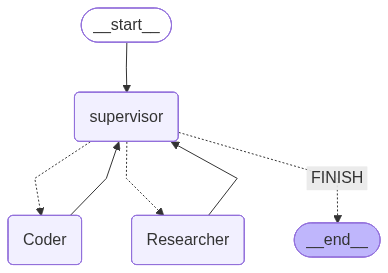

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

# Invoke the team


그래프가 생성되었으니, 이제 이를 호출하고 성능을 확인할 수 있습니다!

In [10]:
for s in graph.stream(
    {
        "messages": [
            HumanMessage(content="Code hello world and print it to the terminal")
        ]
    }
):
    if "__end__" not in s:
        print(s)
        print("----")

{'supervisor': {'next': 'Coder'}}
----


{'Coder': {'messages': [HumanMessage(content='The "Hello, World!" message has been printed to the terminal.', additional_kwargs={}, response_metadata={}, name='Coder')]}}
----
{'supervisor': {'next': 'FINISH'}}
----


In [12]:
for s in graph.stream(
    {"messages": [HumanMessage(content="Write a brief research report on pikas.")]},
    {"recursion_limit": 10},
):
    if "__end__" not in s:
        print(s)
        print("----")

{'supervisor': {'next': 'Researcher'}}
----
{'Researcher': {'messages': [HumanMessage(content='**Title: An Overview of Pikas: Their Ecology, Behavior, and Conservation Status**\n\n**Introduction**\n\nPikas are small, herbivorous mammals belonging to the family Ochotonidae, within the order Lagomorpha, which also includes rabbits and hares. These creatures are well-adapted to cold climates and are primarily found in alpine and mountainous regions. This report offers an insight into their ecological role, behavior, adaptations, and the challenges they face in the wild.\n\n**Ecology and Distribution**\n\nPikas inhabit various regions across the Northern Hemisphere, with significant populations found in North America and Asia. In North America, the American pika (Ochotona princeps) is commonly found in the rocky mountain ranges of the western United States and Canada. Asian species are distributed across diverse habitats, including the Himalayas, Siberia, and Mongolia.\n\n**Physical Charac

In [13]:
for s in graph.stream(
    {"messages": [HumanMessage(content="사막여우에 대한 간략한 리포트를 한글로 작성해줘.")]},
    {"recursion_limit": 10},
):
    if "__end__" not in s:
        print(s)
        print("----")

{'supervisor': {'next': 'Researcher'}}
----
{'Researcher': {'messages': [HumanMessage(content="사막여우(Fennec Fox)는 주로 아프리카의 사하라 사막과 북아프리카 지역에서 서식하는 작은 여우 종입니다. 그들은 세계에서 가장 작은 여우로 알려져 있으며, 몸길이는 24-41cm, 꼬리 길이는 18-31cm 정도입니다. 사막여우의 가장 눈에 띄는 특징은 적응을 통해 발달한 큰 귀로, 이는 체온 조절과 뛰어난 청력을 제공하여 사막 환경에서 살아남는 데 도움을 줍니다.\n\n사막여우는 주로 야행성 동물로, 낮에는 굴에 숨어 휴식하고 밤에 활동하며 먹이를 찾습니다. 그들은 잡식성으로, 주로 곤충, 작은 포유류, 새의 알, 그리고 다양한 과일 등을 먹습니다. 강한 후각과 청각을 통해서 사냥감을 찾습니다.\n\n사회적 동물인 사막여우는 가족 단위로 무리를 지어 생활하며, 이 사회적 구조는 사막 환경에서 생존을 위한 중요한 요소로 작용합니다. 암컷은 보통 한 번에 2-5마리의 새끼를 낳고, 부모 모두가 새끼를 돌보는 데 적극적으로 참여합니다.\n\n사막여우는 국제 자연 보전 연맹(IUCN)에 의해 현재 '관심 미달(Least Concern)'으로 분류되어 있는데, 이는 멸종 위기에는 처하지 않았다는 의미입니다. 그러나 모피 및 애완동물 거래로 인해 지역적인 위협 요소는 존재합니다.\n\n사막여우는 그 독특한 외모와 적응력 덕분에 전 세계적으로 많은 사람들에게 흥미로운 동물로 꼽힙니다.", additional_kwargs={}, response_metadata={}, name='Researcher')]}}
----
{'supervisor': {'next': 'FINISH'}}
----
